# Modelagem e avaliação

O conjunto de dados foi agora limpo, explorado e enriquecido por meio de engenharia de atributos e etapas de pré-processamento. Nos notebooks anteriores, tratamos os valores faltantes, investigamos as relações entre as características dos passageiros e a sobrevivência, criamos novos atributos motivados pelo conhecimento do domínio e codificamos variáveis categóricas em representações numéricas adequadas para aprendizado de máquina.

Neste notebook, passamos da preparação dos dados para a modelagem preditiva. Nosso objetivo é treinar e avaliar diferentes algoritmos de aprendizado de máquina capazes de prever a sobrevivência dos passageiros com base nas informações disponíveis.

Começamos construindo o conjunto final de dados para modelagem utilizando o registro de atributos desenvolvido durante a engenharia de atributos. Esse registro fornece uma especificação transparente e reprodutível dos atributos incluídos em cada modelo.

As próximas seções dividirão os dados em conjuntos de treinamento e validação, treinarão múltiplos modelos de classificação, compararão seus desempenhos preditivos utilizando métricas de avaliação apropriadas e analisarão os pontos fortes e as limitações de cada abordagem.


## Configuração da modelagem

### Importação das bibliotecas

Começamos importando as bibliotecas necessárias para o desenvolvimento e a avaliação dos modelos. Elas incluem ferramentas para manipulação de dados, divisão do conjunto de dados, algoritmos de aprendizado de máquina, métricas de desempenho e visualização dos resultados.


In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

### Carregando os dados

Começamos carregando o conjunto de dados processado e o registro de atributos produzidos no notebook anterior. Neste estágio, todas as etapas de pré-processamento, engenharia de atributos, transformações e codificação já foram concluídas, permitindo que o foco seja exclusivamente o desenvolvimento e a avaliação dos modelos.

O registro de atributos fornece uma especificação centralizada de todos os atributos disponíveis e indica quais variáveis devem ser incluídas nos modelos de aprendizado de máquina.


In [2]:
# Load processed dataset and feature registry
df_full = pd.read_parquet("../data/processed/02_data.parquet")
df_features = pd.read_parquet("../data/processed/02_features.parquet")

In [3]:
df_full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Age_Child,Age_Teen,Age_YoungAdult,Age_Adult,Age_Senior
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,False,False,True,False,False,False,False,True,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,False,False,False,True,False,False,False,False,True,False
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,False,True,False,False,False,False,False,True,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,False,False,False,True,False,False,False,True,False,False
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,False,False,True,False,False,False,False,True,False,False


In [4]:
df_features.head()

,Name,Type,Category,Source,Description,UsedInModel
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec...",True
1,Name,categorical,original,Name,Passenger's full name.,False
2,Sex,indicator,encoded,Sex,"Binary encoding of passenger sex (0 = male, 1 ...",True
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...,True
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...,True


### Separando os conjuntos de treinamento e teste

O conjunto de dados original da competição Kaggle Titanic fornece conjuntos de treinamento e teste separados. Ao longo do pipeline de pré-processamento, essa distinção foi preservada utilizando o indicador `IsTrainSet`. Agora utilizamos esse marcador para reconstruir a divisão original, garantindo que os modelos sejam treinados apenas com os dados rotulados, enquanto o conjunto de teste sem rótulos é mantido para gerar as previsões finais da competição.


In [5]:
feature_names = df_features.loc[
    df_features["UsedInModel"],
    "Name"
]

X_train = df_full.loc[df_full["IsTrainSet"], feature_names]
y_train = df_full.loc[df_full["IsTrainSet"], "Survived"]

X_test = df_full.loc[~df_full["IsTrainSet"], feature_names]

### Seleção de atributos

O [notebook de engenharia de atributos](02_feature_engineering.ipynb) produziu um registro de atributos descrevendo cada variável disponível no conjunto de dados, juntamente com metadados como sua origem, tipo e indicação de inclusão na etapa de modelagem. Utilizamos esse registro para construir a matriz final de atributos, garantindo que o treinamento dos modelos seja baseado em um processo de seleção de variáveis transparente e reprodutível.


In [6]:
# Select features marked for modeling
selected_features = df_features.loc[
    df_features["UsedInModel"],
    "Name"
].tolist()

selected_features

['Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'FamilySize',
 'IsAlone',
 'TicketGroupSize',
 'SqrtAge',
 'LogFare',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S',
 'Title_Master',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Rare',
 'Age_Child',
 'Age_Teen',
 'Age_YoungAdult',
 'Age_Adult',
 'Age_Senior']

## Fundamentos de modelagem

Com os dados preparados, podemos iniciar o treinamento dos primeiros modelos de classificação. Em vez de construir imediatamente um pipeline completo de avaliação, esta seção apresenta as etapas fundamentais envolvidas em classificação supervisionada de forma gradual.

Começamos com um modelo de referência simples e introduzimos progressivamente algoritmos mais sofisticados, utilizando cada um como uma oportunidade para discutir conceitos essenciais como treinamento de modelos, geração de previsões, métricas de avaliação e validação cruzada. Ao compreender primeiro esses componentes básicos, o pipeline automatizado de avaliação desenvolvido posteriormente neste notebook será mais fácil de interpretar e compreender.


## Modelo baseline: classificador dummy

Antes de treinar modelos preditivos, é útil estabelecer uma referência simples contra a qual algoritmos mais sofisticados possam ser comparados. Um modelo baseline fornece um nível de desempenho de referência e ajuda a determinar se a complexidade adicional dos modelos de aprendizado de máquina é justificada.

Para problemas de classificação, um baseline comum é o **classificador dummy**, que ignora completamente os atributos de entrada e realiza previsões de acordo com uma estratégia simples. Neste caso, utilizamos a estratégia **most frequent**, que sempre prevê a classe majoritária observada nos dados de treinamento. Embora essa abordagem seja extremamente simples, qualquer modelo de aprendizado de máquina útil deve ser capaz de superá-la.


### Instanciando o modelo

O primeiro passo é instanciar o classificador Dummy. Diferentemente dos modelos preditivos de aprendizado de máquina, o classificador Dummy não aprende padrões a partir dos atributos de entrada. Em vez disso, ele serve como um baseline simples ao seguir uma estratégia de previsão predefinida.

Neste caso, utilizamos a estratégia **most frequent**, que sempre prevê a classe majoritária observada nos dados de treinamento. Isso fornece um nível de desempenho de referência que modelos mais sofisticados devem ser capazes de superar.


In [7]:
# Instantiate the dummy classifier
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")

### Treinando o modelo

Antes que um modelo de aprendizado de máquina possa realizar previsões, ele precisa ser treinado utilizando os dados rotulados disponíveis. Durante essa etapa de treinamento, o modelo aprende a relação entre os atributos de entrada e a variável alvo.

No entanto, para o classificador Dummy, praticamente não há nada a ser aprendido a partir dos valores dos atributos. A estratégia **most frequent** simplesmente identifica qual classe aparece com maior frequência no conjunto de treinamento e armazena essa informação para realizar previsões futuras.


In [8]:
# Train the baseline classifier
dummy.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


### Realizando previsões

Após o treinamento do modelo, ele pode ser utilizado para prever a variável alvo em novas observações. Neste caso, geramos previsões para o próprio conjunto de treinamento com o objetivo de inspecionar o comportamento do classificador baseline.


In [9]:
# Predict the training set
y_pred = dummy.predict(X_train)

Neste ponto, poderíamos exibir o conteúdo de `y_pred`, mas a saída seria simplesmente um longo vetor de rótulos de classe previstos, difícil de interpretar. Em vez disso, resumimos as previsões contando quantos passageiros o modelo classificou em cada categoria. Isso fornece uma visão muito mais clara do comportamento do modelo.


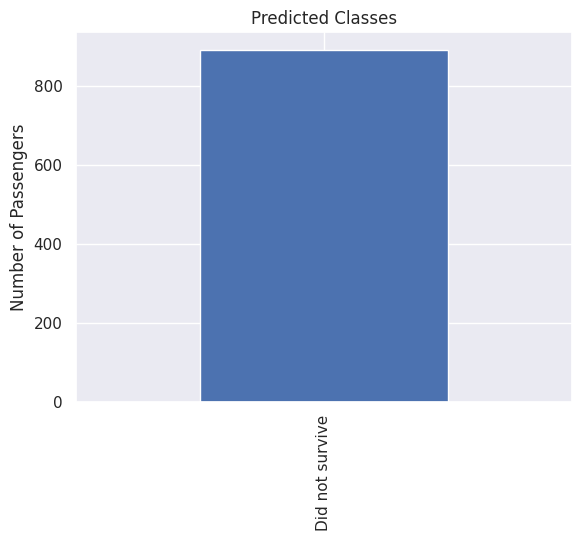

In [10]:
prediction_counts = (
    pd.Series(y_pred)
    .map({
        0: "Did not survive",
        1: "Survived",
    })
    .value_counts()
)

prediction_counts.plot.bar()

plt.title("Predicted Classes")
plt.xlabel("")
plt.ylabel("Number of Passengers")

plt.show()

Como esperado, o vetor de previsões é composto inteiramente por zeros. Como o classificador Dummy utiliza a estratégia **most frequent**, ele ignora todos os atributos de entrada e simplesmente prevê, para cada passageiro, a classe majoritária observada nos dados de treinamento. No conjunto de dados Titanic, a classe majoritária corresponde aos passageiros que **não sobreviveram**, resultando em previsões idênticas para todas as observações.


### Avaliando a acurácia

A acurácia é a métrica mais simples e uma das mais utilizadas em problemas de classificação. Ela mede a proporção de observações que foram classificadas corretamente pelo modelo.

Uma acurácia de 1.0 indica previsões perfeitas, enquanto uma acurácia de 0.5 significa que o modelo classificou corretamente metade das observações. Embora a acurácia forneça uma medida geral útil do desempenho, ela não diferencia os diferentes tipos de erros de classificação. Como veremos posteriormente, métricas adicionais são frequentemente necessárias para obter uma avaliação mais completa de um classificador.


In [11]:
# Compute the training accuracy
accuracy = accuracy_score(y_train, y_pred)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.616


### Discussão

O classificador Dummy alcança uma acurácia que pode parecer inicialmente razoável. No entanto, esse resultado deve ser interpretado com cautela. Como o classificador sempre prevê a classe majoritária, seu desempenho reflete apenas a distribuição das classes no conjunto de dados, e não uma relação significativa entre as características dos passageiros e a sobrevivência.

Esse baseline serve como um ponto de referência útil: espera-se que qualquer modelo de aprendizado de máquina que aprenda a partir dos atributos disponíveis seja capaz de superar essa estratégia simples.


## Regressão logística

Diferentemente do classificador Dummy, que ignora completamente os atributos de entrada, a Regressão Logística aprende uma relação entre as variáveis preditoras e a probabilidade de uma determinada observação pertencer a uma classe específica. É um dos algoritmos mais utilizados para classificação binária devido à sua simplicidade, interpretabilidade e bom desempenho em muitos conjuntos de dados estruturados.

No contexto do conjunto de dados Titanic, o modelo estima a probabilidade de cada passageiro ter sobrevivido com base nos atributos disponíveis. Essas probabilidades são então convertidas em previsões de classe utilizando um limiar de decisão, geralmente igual a 0.5. Dessa forma, a Regressão Logística representa um primeiro passo natural além do baseline, permitindo avaliar quanto poder preditivo está contido nos atributos construídos durante o projeto.


### Instanciando o modelo

O primeiro passo é instanciar o classificador de Regressão Logística. Neste estágio, apenas criamos o objeto do modelo, sem realizar nenhum treinamento. O processo de aprendizado só começa quando o modelo é ajustado aos dados de treinamento.

Neste exemplo, utilizamos a implementação padrão fornecida pelo scikit-learn, especificando apenas um `random_state` fixo para garantir resultados reprodutíveis entre diferentes execuções.


In [12]:
# Instantiate the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
)

### Treinando o modelo

Após a instanciação do modelo, o próximo passo é treiná-lo utilizando os dados rotulados disponíveis. Durante o treinamento, a Regressão Logística aprende a relação entre os atributos de entrada e a variável alvo estimando um conjunto de coeficientes que melhor separa as duas classes.

Diferentemente do classificador Dummy, que ignora os valores dos atributos, a Regressão Logística utiliza os dados de treinamento para identificar padrões que ajudam a distinguir passageiros que sobreviveram daqueles que não sobreviveram.


In [13]:
# Train the Logistic Regression classifier
logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Realizando previsões

Após o treinamento do modelo, ele pode ser utilizado para prever o resultado de sobrevivência de cada passageiro no conjunto de treinamento. Diferentemente do classificador Dummy, que atribui o mesmo rótulo a todas as observações, a Regressão Logística utiliza as relações aprendidas entre os atributos e a variável alvo para produzir previsões individualizadas para cada passageiro.

Essas previsões podem então ser comparadas com os rótulos verdadeiros para avaliar o desempenho do modelo.


In [14]:
# Predict the training set
y_pred = logistic.predict(X_train)

Assim como anteriormente, exibir todo o conteúdo de `y_pred` resultaria em uma longa sequência de rótulos de classe previstos que oferece pouca informação. Em vez disso, resumimos as previsões contando quantos passageiros foram classificados em cada resultado, tornando mais fácil compreender o comportamento geral do modelo.


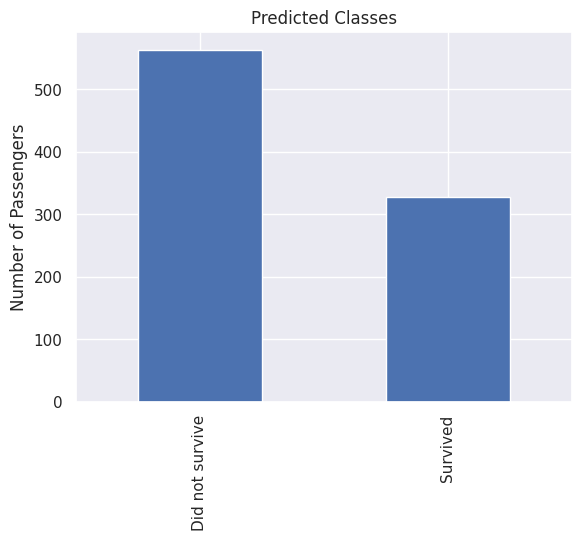

In [15]:
prediction_counts = (
    pd.Series(y_pred)
    .map({
        0: "Did not survive",
        1: "Survived",
    })
    .value_counts()
)

prediction_counts.plot.bar()

plt.title("Predicted Classes")
plt.xlabel("")
plt.ylabel("Number of Passengers")

plt.show()

Diferentemente do classificador Dummy, o vetor de previsões agora contém ambas as classes, indicando que o modelo aprendeu a diferenciar os passageiros com base nos atributos disponíveis.


### Avaliando a acurácia

Começamos calculando a acurácia do modelo de Regressão Logística no conjunto de treinamento. Comparar esse valor com o baseline estabelecido pelo classificador Dummy fornece uma indicação inicial de quanto poder preditivo o modelo aprendeu a partir dos atributos disponíveis.


In [16]:
# Compute the training accuracy
accuracy = accuracy_score(y_train, y_pred)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.835


O modelo de Regressão Logística alcança uma acurácia significativamente maior do que o classificador Dummy, indicando que conseguiu aprender padrões preditivos a partir dos atributos disponíveis. No entanto, a acurácia sozinha não conta toda a história. Para compreender melhor o desempenho do modelo, agora examinamos métricas adicionais de avaliação que caracterizam diferentes aspectos da performance de classificação.


### Avaliando a precisão

Enquanto a acurácia fornece uma medida geral do desempenho, a precisão permite avaliar quão confiáveis são as previsões positivas do modelo. Para o problema do Titanic, isso significa analisar com que frequência os passageiros previstos como sobreviventes eram de fato sobreviventes.

Agora calculamos a métrica de precisão para compreender melhor o tipo de erros cometidos pelo modelo de Regressão Logística.


In [17]:
# Compute precision
precision = precision_score(
    y_train,
    y_pred,
)

print(f"Precision: {precision:.3f}")

Precision: 0.798


A métrica de precisão fornece informações adicionais sobre o comportamento do modelo de Regressão Logística além da acurácia geral. Comparado ao classificador Dummy, o modelo agora é capaz de identificar alguns passageiros como sobreviventes, mas essas previsões não estão todas corretas.

Isso destaca por que múltiplas métricas de avaliação são necessárias em problemas de classificação. Um modelo pode alcançar uma acurácia razoável e ainda assim produzir um número considerável de previsões positivas incorretas. A precisão ajuda a quantificar especificamente esse aspecto do desempenho do modelo.


### Avaliando o recall

O recall fornece outra perspectiva sobre o modelo de Regressão Logística ao medir sua capacidade de identificar corretamente os passageiros que sobreviveram. Enquanto a precisão se concentra na confiabilidade das previsões positivas, o recall avalia quantos dos sobreviventes reais foram detectados corretamente pelo modelo.

Agora calculamos o recall para avaliar com que eficiência o classificador captura a classe positiva.


In [18]:
# Compute recall
recall = recall_score(
    y_train,
    y_pred,
)

print(f"Recall: {recall:.3f}")

Recall: 0.763


A métrica de recall mostra a eficiência da Regressão Logística em identificar passageiros que sobreviveram. Comparar o recall com a precisão ajuda a revelar o tipo de compromisso realizado pelo modelo: aumentar a detecção de sobreviventes pode ocorrer ao custo de produzir mais falsos positivos, enquanto uma postura mais seletiva pode aumentar a precisão, mas deixar de identificar alguns sobreviventes.

Esse compromisso é um aspecto fundamental dos problemas de classificação e é uma das razões pelas quais depender de uma única métrica pode levar a interpretações equivocadas.


### Avaliando o F1-score

O F1-score fornece uma única métrica que combina precisão e recall, oferecendo uma visão equilibrada da capacidade do modelo de identificar sobreviventes enquanto mantém previsões positivas confiáveis.

Como precisão e recall capturam diferentes aspectos do desempenho de classificação, o F1-score é útil quando desejamos considerar simultaneamente esses dois tipos de erro. Agora calculamos o F1-score para resumir o desempenho do modelo de Regressão Logística na classe positiva.


In [19]:
# Compute F1-score
f1 = f1_score(
    y_train,
    y_pred,
)

print(f"F1-score: {f1:.3f}")

F1-score: 0.780


O F1-score fornece uma visão mais completa do desempenho do modelo de Regressão Logística do que a acurácia isoladamente. Ao combinar precisão e recall, ele reflete o equilíbrio entre identificar corretamente os sobreviventes e evitar previsões incorretas de sobrevivência.

Juntamente com acurácia, precisão e recall, o F1-score oferece uma compreensão mais ampla do comportamento do classificador e prepara a base para uma análise mais detalhada utilizando a matriz de confusão.


### Visualizando a matriz de confusão

A matriz de confusão fornece uma visão mais detalhada das previsões do modelo de Regressão Logística, mostrando o número de classificações corretas e incorretas para cada classe.

Enquanto métricas como acurácia, precisão, recall e F1-score resumem o desempenho do modelo em valores únicos, a matriz de confusão permite inspecionar diretamente os tipos de erro cometidos pelo classificador. Isso ajuda a identificar se o modelo tende a classificar incorretamente com maior frequência passageiros sobreviventes ou não sobreviventes.


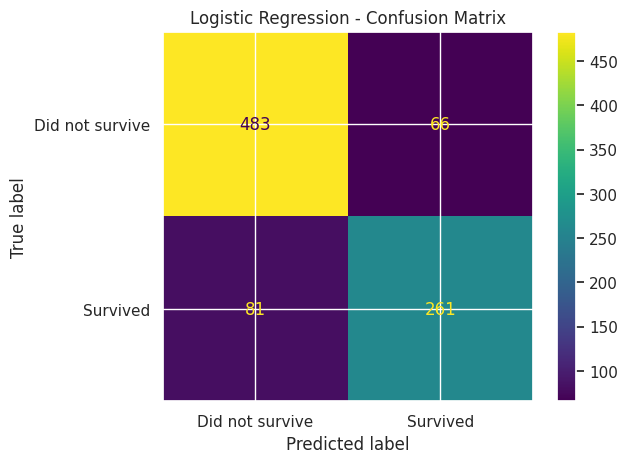

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred,
    display_labels=["Did not survive", "Survived"],
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

A matriz de confusão mostra que a Regressão Logística é capaz de identificar ambas as classes, diferentemente do classificador Dummy, que previa apenas a classe majoritária. No entanto, o modelo ainda comete dois tipos de erro: prever sobrevivência para passageiros que não sobreviveram e deixar de identificar alguns passageiros que de fato sobreviveram.

Esses erros correspondem diretamente aos conceitos capturados pelas métricas de precisão e recall, fornecendo uma explicação visual do compromisso existente entre essas duas medidas.


Avaliando com validação cruzada

Até agora, as métricas de avaliação foram calculadas utilizando os mesmos dados que foram usados para treinar o modelo. Embora isso forneça informações sobre o quanto o modelo se ajusta aos dados de treinamento, esse procedimento não oferece uma estimativa confiável de como ele irá se comportar em observações não vistas.

A validação cruzada aborda essa limitação realizando múltiplas divisões do conjunto de treinamento em diferentes subconjuntos. O modelo é treinado em uma parte dos dados e avaliado na parte restante, permitindo estimar com que consistência ele apresenta desempenho em diferentes amostras.

Para problemas de classificação, utilizamos a validação cruzada Stratified K-Fold, que preserva a proporção de cada classe em todos os folds. Isso é particularmente importante para o conjunto de dados Titanic, pois as classes de sobrevivência não são perfeitamente balanceadas.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# Evaluate model using cross-validation
cv_scores = cross_val_score(
    logistic,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
)

print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Cross-validation accuracy: 0.832 ± 0.005


### Discussão

A acurácia obtida por validação cruzada é próxima da acurácia de treinamento, sugerindo que a Regressão Logística generaliza de forma razoável para diferentes subconjuntos dos dados de treinamento. A pequena variação entre os folds indica que o desempenho do modelo é relativamente consistente.

A partir deste ponto, a validação cruzada será incorporada ao fluxo de avaliação de todos os modelos subsequentes, fornecendo uma base mais confiável para comparação entre diferentes abordagens.


## Automatizando o pipeline de avaliação

As seções anteriores apresentaram, passo a passo, os procedimentos de treinamento e avaliação de modelos de classificação. Após estabelecer o fluxo completo de avaliação, agora encapsulamos as operações repetidas em funções auxiliares reutilizáveis.

Os modelos baseline e de Regressão Logística são revisitados utilizando esse novo pipeline, com o objetivo de verificar se a implementação automatizada reproduz os mesmos resultados obtidos anteriormente antes de estender a comparação para classificadores adicionais.


### Funções auxiliares

O processo de avaliação utilizado para a Regressão Logística envolveu várias etapas repetidas: treinamento do modelo, geração de previsões, cálculo das métricas de avaliação e estimativa do desempenho por meio de validação cruzada.

Como essas operações serão repetidas para todos os classificadores considerados neste projeto, encapsulamos essas etapas em uma função reutilizável. Isso garante que todos os modelos sejam avaliados utilizando o mesmo procedimento, tornando a comparação entre algoritmos mais consistente e reduzindo a duplicação de código.


In [22]:
import time

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def evaluate_model(
    model,
    model_name,
    X,
    y,
):
    """
    Train and evaluate a classification model.

    Parameters
    ----------
    model : estimator
        Scikit-learn classifier.

    model_name : str
        Name of the model.

    X : pandas.DataFrame
        Input features.

    y : pandas.Series
        Target variable.

    Returns
    -------
    model
        The fitted model.

    dict
        Dictionary containing evaluation metrics.
    """

    # Stratified cross-validation
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    # Train the model
    start = time.perf_counter()

    model.fit(X, y)

    training_time = time.perf_counter() - start

    # Predictions
    y_pred = model.predict(X)

    # Prediction probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = model.decision_function(X)

    # Cross-validation
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    # Evaluation metrics
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(
            y,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y,
            y_pred,
            zero_division=0,
        ),
        "F1Score": f1_score(
            y,
            y_pred,
            zero_division=0,
        ),
        "ROCAUC": roc_auc_score(
            y,
            y_score,
        ),
        "CVAccuracyMean": cv_scores.mean(),
        "CVAccuracyStd": cv_scores.std(),
        "TrainingTimeSeconds": training_time,
    }

    return model, results

#### Tabela de resultados

Para comparar diferentes classificadores de forma consistente, armazenamos os resultados de avaliação de cada modelo em uma única tabela. Isso permite acompanhar o desempenho de múltiplos algoritmos utilizando o mesmo conjunto de métricas e torna a comparação final entre os modelos mais transparente.

A tabela de resultados será atualizada à medida que novos modelos forem treinados e avaliados ao longo do restante do notebook.


In [23]:
# Initialize results storage
results = []

# Create results dataframe
df_results = pd.DataFrame(results)

### Baseline: classificador Dummy

O classificador Dummy é reavaliado utilizando o novo pipeline de avaliação para confirmar que o fluxo automatizado reproduz os resultados do baseline obtidos anteriormente. Como esse modelo fornece um nível de referência de desempenho, manter a consistência nesta etapa é importante antes de avançarmos para classificadores mais complexos.


In [24]:
dummy, result = evaluate_model(
    model=dummy,
    model_name="Dummy classifier",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.0,0.0,0.0,0.5,0.616163,0.002325,0.000757


### Regressão logística

A Regressão Logística também é avaliada utilizando o pipeline automatizado. Essa etapa serve como uma segunda validação, confirmando que o pipeline é capaz de lidar corretamente com um modelo preditivo que aprende a partir dos atributos de entrada e calcula o conjunto completo de métricas de avaliação e resultados de validação cruzada.


In [25]:
logistic, result = evaluate_model(
    model=logistic,
    model_name="Logistic regression",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000757
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.050350


### Árvore de decisão

Árvores de decisão são modelos de aprendizado supervisionado que realizam previsões dividindo os dados recursivamente de acordo com os valores dos atributos. Cada divisão cria uma regra de decisão que separa as observações em grupos progressivamente mais homogêneos, resultando em uma estrutura de decisões em formato de árvore.

Diferentemente da Regressão Logística, que modela uma relação linear entre os atributos e a probabilidade da variável alvo, as Árvores de Decisão conseguem capturar naturalmente relações não lineares e interações entre variáveis. Isso torna esse modelo uma alternativa interessante para avaliação em conjuntos de dados tabulares estruturados, como o conjunto Titanic.

O modelo é treinado e avaliado utilizando o mesmo pipeline introduzido anteriormente, garantindo que seu desempenho possa ser comparado diretamente com os classificadores anteriores.


In [26]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
)

decision_tree, result = evaluate_model(
    model=decision_tree,
    model_name="Decision tree",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000757
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.050350
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.003598


### Random forest

Random Forest é um algoritmo de aprendizado por ensemble que combina múltiplas Árvores de Decisão para produzir um classificador mais robusto. Em vez de depender de uma única árvore, o algoritmo treina várias árvores independentes utilizando diferentes subconjuntos dos dados e dos atributos, combinando suas previsões para melhorar a capacidade de generalização.

Comparadas a uma única Árvore de Decisão, as Random Forests geralmente são menos sensíveis a pequenas variações nos dados de treinamento e apresentam maior capacidade de reduzir o overfitting. Por esse motivo, são amplamente utilizadas como modelos baseline fortes para conjuntos de dados tabulares estruturados.

O modelo é treinado e avaliado utilizando o mesmo pipeline introduzido anteriormente, permitindo uma comparação direta com os demais classificadores.


In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state=42,
)

random_forest, result = evaluate_model(
    model=random_forest,
    model_name="Random forest",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000757
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.050350
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.003598
3,Random forest,0.984287,0.988095,0.970760,0.979351,0.997622,0.824914,0.004274,0.086412


### Gradient Boosting

Gradient Boosting é um algoritmo de aprendizado por ensemble que constrói uma sequência de modelos fracos, geralmente árvores de decisão, em que cada novo modelo busca corrigir os erros cometidos pelos modelos anteriores.

Diferentemente da Random Forest, que treina múltiplas árvores de forma independente e combina suas previsões, o Gradient Boosting treina as árvores sequencialmente, aprimorando gradualmente o modelo ao dar maior atenção às observações que são mais difíceis de classificar. Isso permite capturar padrões complexos nos dados, embora possa exigir um ajuste mais cuidadoso para evitar overfitting.

Assim como nos classificadores anteriores, o modelo é avaliado utilizando o mesmo pipeline, garantindo uma comparação consistente entre os diferentes algoritmos.


In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    random_state=42,
)

gradient_boosting, result = evaluate_model(
    model=gradient_boosting,
    model_name="Gradient boosting",
    X=X_train,
    y=y_train,
)

results.append(result)

df_results = pd.DataFrame(results)

df_results

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000757
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.050350
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.003598
3,Random forest,0.984287,0.988095,0.970760,0.979351,0.997622,0.824914,0.004274,0.086412
4,Gradient boosting,0.898990,0.906452,0.821637,0.861963,0.952476,0.839502,0.007706,0.110912


## Comparação dos modelos

Após avaliar múltiplos classificadores utilizando o mesmo pipeline automatizado, podemos agora comparar seus desempenhos e identificar quais modelos apresentam os melhores resultados para este problema de classificação.

A comparação é baseada nas métricas de avaliação armazenadas em `df_results`, incluindo desempenho no conjunto de treinamento, acurácia obtida por validação cruzada e ROC-AUC. Embora cada métrica individual forneça informações úteis, a seleção do modelo deve considerar o equilíbrio geral entre desempenho preditivo, capacidade de generalização e custo computacional.

Os resultados de validação cruzada são particularmente importantes, pois fornecem uma estimativa mais confiável de como cada modelo deve se comportar em dados não observados.

### Comparando o desempenho dos modelos


In [29]:
# Sort models by cross-validation accuracy
df_results.sort_values(
    by="CVAccuracyMean",
    ascending=False,
)

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC,CVAccuracyMean,CVAccuracyStd,TrainingTimeSeconds
4,Gradient boosting,0.898990,0.906452,0.821637,0.861963,0.952476,0.839502,0.007706,0.110912
1,Logistic regression,0.835017,0.798165,0.763158,0.780269,0.877622,0.831643,0.005237,0.050350
3,Random forest,0.984287,0.988095,0.970760,0.979351,0.997622,0.824914,0.004274,0.086412
2,Decision tree,0.984287,0.993976,0.964912,0.979228,0.999385,0.806936,0.019526,0.003598
0,Dummy classifier,0.616162,0.000000,0.000000,0.000000,0.500000,0.616163,0.002325,0.000757


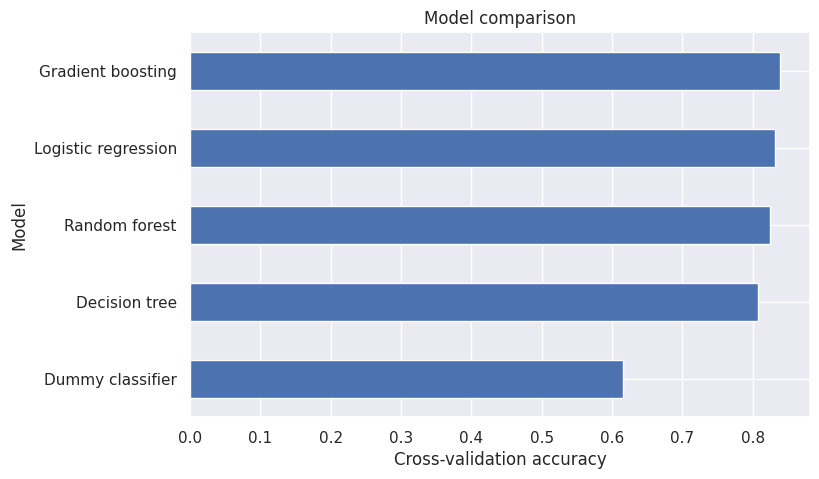

In [30]:
import matplotlib.pyplot as plt

df_results.sort_values(
    "CVAccuracyMean"
).plot(
    x="Model",
    y="CVAccuracyMean",
    kind="barh",
    legend=False,
    figsize=(8, 5),
)

plt.xlabel("Cross-validation accuracy")
plt.ylabel("Model")
plt.title("Model comparison")
plt.show()

Os resultados mostram que os diferentes classificadores apresentam níveis variados de desempenho preditivo. O classificador Dummy fornece o baseline esperado, enquanto os modelos de aprendizado de máquina superam essa referência ao aprender padrões a partir dos atributos dos passageiros.

Entre os modelos avaliados, o classificador com melhor desempenho é selecionado com base em uma combinação do desempenho obtido por validação cruzada e de métricas complementares, como ROC-AUC, precisão, recall e F1-score. A escolha final deve priorizar não apenas a maior pontuação, mas também um desempenho consistente entre os diferentes critérios de avaliação.


### Curvas ROC

Enquanto métricas como acurácia e F1-score resumem o desempenho dos modelos utilizando um único valor, a curva Receiver Operating Characteristic (ROC) fornece uma visão mais completa do comportamento de um classificador em diferentes limiares de decisão.

A curva ROC representa a relação entre a **Taxa de Verdadeiros Positivos (Recall)** e a **Taxa de Falsos Positivos** à medida que o limiar de classificação varia. Modelos cujas curvas estão mais próximas do canto superior esquerdo geralmente apresentam melhor capacidade de discriminar entre as duas classes.

A **Área sob a Curva ROC (ROC-AUC)** resume esse comportamento em um único valor entre 0 e 1. Um valor de 0.5 corresponde a uma classificação equivalente ao acaso, enquanto valores mais próximos de 1 indicam melhor separação entre as classes.

A figura abaixo compara as curvas ROC de todos os classificadores avaliados.


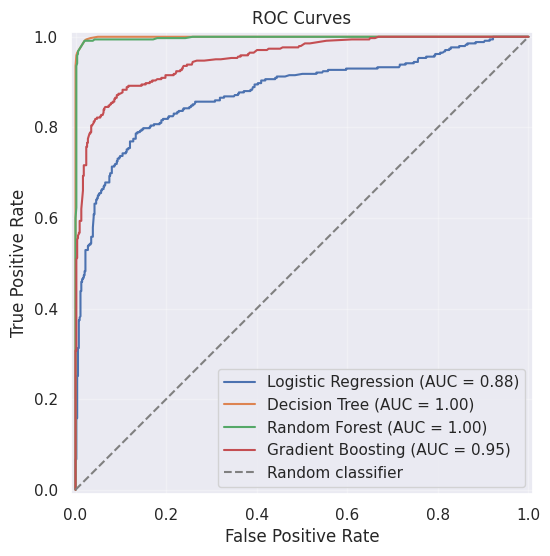

In [31]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_train,
        y_train,
        ax=plt.gca(),
        name=name,
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

As curvas ROC confirmam a comparação numérica apresentada anteriormente. Os modelos cujas curvas permanecem mais próximas do canto superior esquerdo apresentam melhor capacidade de discriminar entre passageiros que sobreviveram e aqueles que não sobreviveram.

Entre os classificadores avaliados, os métodos de ensemble apresentam o melhor desempenho geral, com o Gradient Boosting alcançando o maior ROC-AUC. A Regressão Logística apresenta desempenho competitivo apesar de sua simplicidade, enquanto a Árvore de Decisão e a Random Forest alcançam excelente capacidade de discriminação nos dados de treinamento, mas apresentam desempenho inferior na validação cruzada, sugerindo uma maior tendência ao overfitting.

Essas observações reforçam a importância de considerar tanto o desempenho no treinamento quanto os resultados de validação cruzada ao selecionar o modelo final.


### Matrizes de confusão

Enquanto a curva ROC resume o desempenho dos modelos considerando todos os possíveis limiares de decisão, a matriz de confusão avalia as previsões obtidas utilizando o limiar de classificação padrão.

Cada matriz de confusão apresenta o número de **Verdadeiros Positivos (TP)**, **Verdadeiros Negativos (TN)**, **Falsos Positivos (FP)** e **Falsos Negativos (FN)**. A análise desses valores ajuda a identificar os tipos de erro cometidos por cada classificador e fornece informações adicionais além das métricas agregadas de desempenho.

A figura a seguir compara as matrizes de confusão dos modelos avaliados.


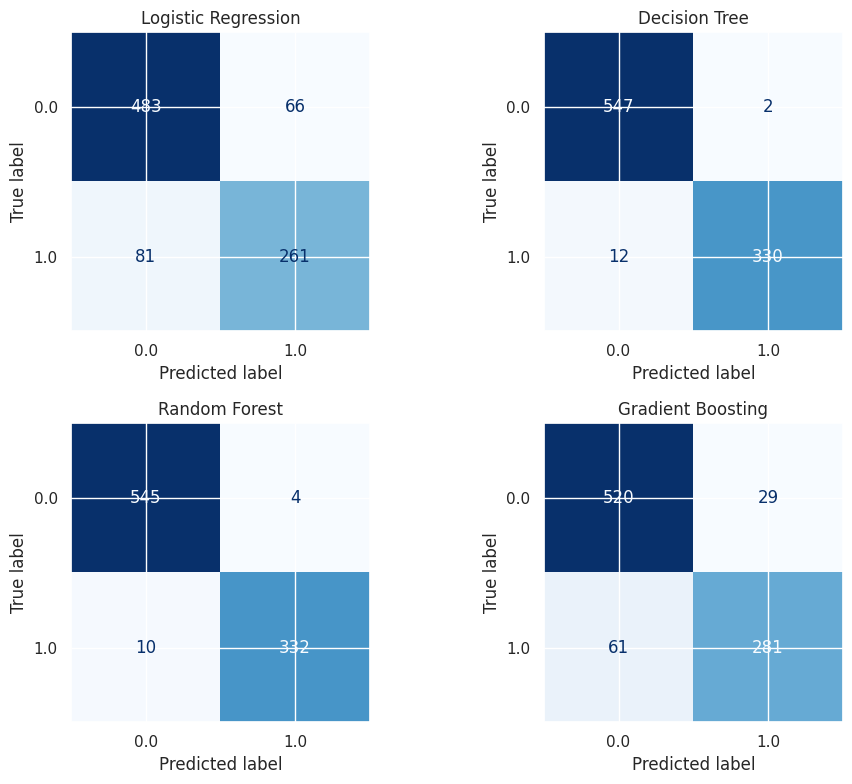

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
)

models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}

for ax, (name, model) in zip(axes.ravel(), models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_train,
        y_train,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

As matrizes de confusão ilustram como os diferentes classificadores equilibram classificações corretas e erros de previsão.

A Regressão Logística apresenta um desempenho de classificação bem equilibrado, mantendo uma boa capacidade de generalização. A Árvore de Decisão e a Random Forest classificam corretamente praticamente todas as observações de treinamento, resultando em poucos erros. No entanto, esse desempenho quase perfeito nos dados de treinamento, combinado com a menor acurácia obtida por validação cruzada, indica que esses modelos provavelmente estão sofrendo de overfitting.

O Gradient Boosting também alcança excelente desempenho de classificação, mantendo resultados mais fortes na validação cruzada, o que sustenta sua seleção como o modelo final deste projeto.


## Modelo final

Após comparar os classificadores avaliados, selecionamos o modelo final com base em seu desempenho geral e em sua capacidade de generalização para dados não observados.

O modelo escolhido não é necessariamente aquele que apresenta o maior valor em uma única métrica, mas sim aquele que oferece o melhor equilíbrio entre desempenho preditivo, consistência entre os folds da validação cruzada e comportamento de classificação adequado para o problema.

Após a seleção, o classificador final é retreinado utilizando todo o conjunto de dados de treinamento e será utilizado para gerar previsões para o conjunto de teste da competição Kaggle.

### Selecionando o modelo final


In [33]:
# Select final model
final_model = gradient_boosting

### Retreinando o modelo final


In [34]:
# Train final model using all available training data
final_model.fit(
    X_train,
    y_train,
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Importância dos atributos

Após selecionar e retreinar o modelo final, podemos agora examinar quais atributos mais contribuíram para suas previsões.

O Gradient Boosting estima a importância relativa de cada variável preditora com base na quantidade de redução do erro de classificação proporcionada por cada atributo ao longo do conjunto de árvores de decisão. Embora esses valores de importância não devam ser interpretados como relações causais, eles fornecem informações úteis sobre quais variáveis o modelo considerou mais informativas para distinguir entre sobreviventes e não sobreviventes.


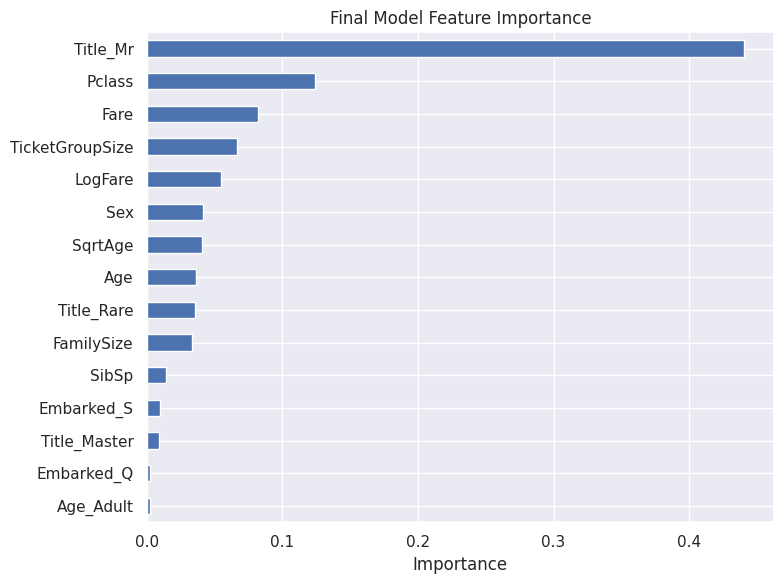

In [35]:
feature_importance = (
    pd.Series(
        final_model.feature_importances_,
        index=X_train.columns,
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

feature_importance.head(15).sort_values().plot.barh()

plt.title("Final Model Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

Os rankings de importância dos atributos mostram que o modelo depende principalmente de um subconjunto relativamente pequeno de variáveis preditoras. Atributos relacionados às características demográficas dos passageiros, classe do bilhete, tarifa, idade e atributos construídos durante a engenharia de atributos apresentam as maiores contribuições para as decisões de classificação, enquanto as demais variáveis desempenham um papel comparativamente menor.

Esses resultados são consistentes com a análise exploratória realizada anteriormente no projeto, reforçando a ideia de que o processo de engenharia de atributos conseguiu capturar informações relevantes a partir do conjunto de dados original.


### Gerando previsões


In [36]:
# Predict test set
y_test_pred = final_model.predict(X_test)

O modelo final agora está treinado utilizando todos os dados rotulados disponíveis, maximizando a quantidade de informação utilizada durante o treinamento. Suas previsões são geradas no conjunto de teste não observado e serão utilizadas para criar o arquivo de submissão do Kaggle.

Neste estágio, o fluxo de modelagem está completo: a etapa restante é formatar as previsões de acordo com os requisitos da competição e gerar o arquivo final de submissão.


In [37]:
final_model = gradient_boosting

## Submissão no Kaggle

A etapa final do fluxo de trabalho consiste em gerar um arquivo de submissão contendo as previsões produzidas pelo modelo selecionado no conjunto de teste do Kaggle.

A competição exige que as previsões sejam fornecidas em um formato específico, contendo o identificador do passageiro e o resultado de sobrevivência previsto. Dessa forma, as previsões geradas pelo classificador final são combinadas com os respectivos valores de `PassengerId` e exportadas como um arquivo CSV pronto para submissão.

### Criando o arquivo de submissão


In [38]:
test_ids = (
    df_full.loc[~df_full["IsTrainSet"], "PassengerId"]
    .reset_index(drop=True)
)

submission = pd.DataFrame(
    {
        "PassengerId": test_ids,
        "Survived": y_test_pred,
    }
)

submission.head()

,PassengerId,Survived
0,892,0.0
1,893,0.0
2,894,0.0
3,895,0.0
4,896,0.0


### Salvando a submissão


In [39]:
submission.to_csv(
    "../data/processed/submission.csv",
    index=False,
)

O arquivo gerado segue o formato exigido pela competição Kaggle Titanic e pode ser enviado para avaliar o desempenho do modelo nos rótulos ocultos do conjunto de teste.

Isso conclui o fluxo completo de classificação, abrangendo exploração dos dados, tratamento de valores ausentes, engenharia de atributos, desenvolvimento de modelos, avaliação de desempenho, comparação entre modelos e geração de previsões.

## Considerações finais

Este projeto demonstrou um fluxo completo de aprendizado de máquina supervisionado utilizando o conjunto de dados Kaggle Titanic. Partindo dos dados brutos, exploramos o conjunto de dados, tratamos valores ausentes, criamos atributos relevantes, treinamos e avaliamos múltiplos modelos de classificação, comparamos seus desempenhos utilizando tanto métricas de validação quanto validação cruzada e geramos uma submissão válida para a competição Kaggle.

Embora a competição Titanic seja frequentemente considerada um problema introdutório de aprendizado de máquina, ela oferece uma excelente oportunidade para ilustrar muitos dos conceitos fundamentais envolvidos em modelagem preditiva aplicada. Ao longo do projeto, o foco esteve na construção de um fluxo de trabalho reprodutível, na compreensão de cada etapa do processo de modelagem e na interpretação dos resultados, em vez de simplesmente maximizar o desempenho na competição.

As técnicas apresentadas aqui — incluindo análise exploratória de dados, engenharia de atributos, avaliação de modelos, validação cruzada e comparação entre algoritmos — formam a base de muitos problemas práticos de classificação encontrados em ciência de dados. Tópicos mais avançados, como otimização de hiperparâmetros, métodos de ensemble, calibração de probabilidades e interpretabilidade de modelos, podem ser incorporados naturalmente a partir deste fluxo de trabalho.

Espero que este projeto sirva tanto como uma introdução prática para aqueles que estão aprendendo aprendizado de máquina quanto como uma referência útil para o desenvolvimento de futuros modelos de classificação.
